# Proyecto Integrador: Diagnóstico Data-Driven del Registro de Nacimientos en Bolivia (2009-2015)

---

## Información del Curso

| Campo | Detalle |
|-------|---------|
| **Programa** | Diplomado en Big Data, Analytics y Business Intelligence v1 |
| **Módulo** | Módulo 1: Transformación Digital y Fundamentos de Big Data |
| **Docente** | Lic. Marcelo Pinto Macedo |
| **Estudiante** | Lic. Ilian Joseph Felipez Vaca |

## 1. Contexto del dataset

**Origen del dataset**

El dataset fue obtenido del **Portal de Datos Abiertos de Bolivia** ([datos.gob.bo](https://datos.gob.bo)), específicamente del conjunto denominado *"Cantidad de nacimientos registrados, 2009-2015"*, disponible en el siguiente enlace: [https://datos.gob.bo/dataset/cantidad-de-nacimientos-registrados-2009-20152](https://datos.gob.bo/dataset/cantidad-de-nacimientos-registrados-2009-20152).

**Institución o plataforma que lo publica**

La información es publicada por el **Ministerio de Salud del Estado Plurinacional de Bolivia**, a través del **Sistema Nacional de Información en Salud (SNIS)**. Los archivos originales fueron descargados directamente de la plataforma en formato CSV para su posterior procesamiento y análisis.

**Problema o fenómeno que representa**

El dataset documenta el fenómeno de los **nacimientos ocurridos en Bolivia entre 2009 y 2015**, desagregando entre nacidos vivos y nacidos muertos (defunciones fetales). Además, incorpora información sobre la atención recibida por personal de salud, lo que permite evaluar si los partos fueron asistidos por profesionales médicos o si ocurrieron fuera del sistema institucional. El período de cobertura abarca 7 años, con registros a nivel municipal y departamental.

**Relevancia del análisis**

El análisis de estos datos es relevante porque:
- Permite realizar el **seguimiento institucional de los hechos vitales**, proporcionando una base objetiva para la planificación de servicios de salud, educación y programas sociales.
- Facilita la **evaluación de la capacidad de respuesta del personal de salud en cada municipio**, identificando brechas de cobertura y zonas con acceso limitado a atención profesional.
- Contribuye a la **detección de riesgos en salud neonatal**, al analizar las tasas de mortalidad fetal en relación con la atención recibida.
- Provee **evidencia para la toma de decisiones estratégicas**, orientando la asignación de recursos, el despliegue de brigadas móviles y el fortalecimiento de la infraestructura sanitaria en territorios prioritarios.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ============================================================================
# CARGA DE DATOS
# ============================================================================

print("="*60)
print("CARGA DE DATOS - REGISTRO DE NACIMIENTOS BOLIVIA 2009-2015")
print("="*60)

# Base URL de GitHub (raw)
base_url = "https://raw.githubusercontent.com/ElTioCrack/BigData-BI-Diploma/main/homeworks/Tarea%204/data_nacimientos/"

# Nombres de los archivos
archivos = [
    "minsalud_registro_nacidos_2009.csv",
    "minsalud_registro_nacidos_2010.csv",
    "minsalud_registro_nacidos_2011.csv",
    "minsalud_registro_nacidos_2012.csv",
    "minsalud_registro_nacidos_2013.csv",
    "minsalud_registro_nacidos_2014.csv",
    "minsalud_registro_nacidos_2015.csv"
]

# Diccionario para almacenar los dataframes por año
data_por_anio = {}

# Cargar cada archivo con manejo de codificaciones
for archivo in archivos:
    url = base_url + archivo
    anio = archivo.split('_')[-1].replace('.csv', '')

    try:
        df = pd.read_csv(url, encoding='utf-8')
        df['anio'] = anio
        data_por_anio[anio] = df
        print(f"[OK] Cargado: {archivo} (utf-8) - {len(df)} registros")
    except UnicodeDecodeError:
        try:
            df = pd.read_csv(url, encoding='latin-1')
            df['anio'] = anio
            data_por_anio[anio] = df
            print(f"[OK] Cargado: {archivo} (latin-1) - {len(df)} registros")
        except Exception as e:
            print(f"[ERROR] Error al cargar {archivo}: {e}")
    except Exception as e:
        print(f"[ERROR] Error al cargar {archivo}: {e}")

print("-"*60)
print(f"Años cargados: {list(data_por_anio.keys())}")
print("="*60)

CARGA DE DATOS - REGISTRO DE NACIMIENTOS BOLIVIA 2009-2015
[OK] Cargado: minsalud_registro_nacidos_2009.csv (latin-1) - 324 registros
[OK] Cargado: minsalud_registro_nacidos_2010.csv (utf-8) - 334 registros
[OK] Cargado: minsalud_registro_nacidos_2011.csv (utf-8) - 333 registros
[OK] Cargado: minsalud_registro_nacidos_2012.csv (utf-8) - 339 registros
[OK] Cargado: minsalud_registro_nacidos_2013.csv (utf-8) - 339 registros
[OK] Cargado: minsalud_registro_nacidos_2014.csv (utf-8) - 336 registros
[OK] Cargado: minsalud_registro_nacidos_2015.csv (utf-8) - 337 registros
------------------------------------------------------------
Años cargados: ['2009', '2010', '2011', '2012', '2013', '2014', '2015']


## 2. Descripción de la estructura de los datos

### 2.1 Estructura original

Los archivos originales descargados del Portal de Datos Abiertos de Bolivia para el período 2009-2015 contienen las siguientes variables:

| Variable | Tipo | Significado |
|----------|------|-------------|
| **id** | Numérica | Identificador único del registro. |
| **cod_dep** | Numérica | Código numérico del departamento. |
| **departamento** | Categórica | Nombre del departamento. |
| **cod_mun** | Numérica | Código numérico del municipio. |
| **municipio** | Categórica | Nombre del municipio. |
| **nacidos_vivos** | Numérica | Conteo de nacidos vivos registrados. |
| **nacidos_vivos_atendidos_por_personal_de_salud** | Numérica | Número de nacidos vivos atendidos por personal de salud. |
| **nacidos_muertos** | Numérica | Conteo de nacidos muertos (mortinatos). |
| **nacidos_muertos_atendidos_por_personal_de_salud** | Numérica | Número de nacidos muertos atendidos por personal de salud. |
| **total_general** | Numérica | Suma total de nacimientos (vivos + muertos). |

**Nota:** El archivo correspondiente al año 2015 incluye una columna adicional denominada `nacidos_muertos_atendidos_por_partera`, la cual no está presente en los archivos de los años anteriores. Esta columna fue excluida del análisis por no contar con datos comparables en toda la serie temporal.


### 2.2 Estructura luego del proceso de limpieza y estandarización

Luego de aplicar los procesos de consolidación, limpieza y estandarización, se obtuvo un dataset unificado con las siguientes variables:

| Variable | Tipo | Significado |
|----------|------|-------------|
| **id** | Numérica | Identificador único del registro a nivel municipal. |
| **cod_dep** | Numérica | Código institucional asignado al departamento. |
| **departamento** | Categórica | Nombre del departamento estandarizado (ejemplo: CHUQUISACA, LA PAZ, SANTA CRUZ). |
| **cod_mun** | Categórica | Código único del municipio, estandarizado a 5 dígitos. |
| **municipio** | Categórica | Nombre del municipio corregido (ejemplo: SUCRE, EL ALTO, COCHABAMBA). |
| **nacidos_vivos** | Numérica | Conteo total de nacimientos ocurridos con vida en el municipio. |
| **nacidos_vivos_atendidos_por_personal_de_salud** | Numérica | Número de nacidos vivos atendidos por personal médico o de salud calificado. |
| **nacidos_muertos** | Numérica | Conteo de nacidos muertos (mortinatos o defunciones fetales) registrados. |
| **nacidos_muertos_atendidos_por_personal_de_salud** | Numérica | Número de nacidos muertos cuya atención fue brindada por personal de salud. |
| **total_general** | Numérica | Sumatoria total de nacimientos en el municipio, equivalente a nacidos vivos más nacidos muertos. |
| **anio** | Categórica | Año de registro del dato, comprendido entre 2009 y 2015. |

In [5]:
# ============================================================================
# LIMPIEZA Y ESTANDARIZACIÓN DE DATOS
# ============================================================================

print("="*60)
print("LIMPIEZA Y ESTANDARIZACIÓN DE DATOS")
print("="*60)

# ----------------------------------------------------------------------------
# CONFIGURACIÓN INICIAL
# ----------------------------------------------------------------------------

# Definir columnas estándar (excluyendo columna de partera solo presente en 2015)
columnas_estandar = [
    'id',
    'cod_dep',
    'departamento',
    'cod_mun',
    'municipio',
    'nacidos_vivos',
    'nacidos_vivos_atendidos_por_personal_de_salud',
    'nacidos_muertos',
    'nacidos_muertos_atendidos_por_personal_de_salud',
    'total_general'
]

# Lista para almacenar dataframes limpios
dataframes_limpios = []

# ----------------------------------------------------------------------------
# FUNCIONES AUXILIARES
# ----------------------------------------------------------------------------

def normalizar_texto(texto):
    """
    Normaliza texto corrigiendo caracteres especiales mal codificados.
    Específicamente diseñado para resolver problemas de codificación en datos bolivianos.
    """
    if not isinstance(texto, str):
        return texto

    # Paso 1: Corregir ñ y Ñ mal codificadas
    texto = texto.replace('Ã±', 'ñ')
    texto = texto.replace('Ã‘', 'Ñ')
    texto = texto.replace('�', 'ñ')
    texto = texto.replace('Ñ', 'Ñ')
    texto = texto.replace('ñ', 'ñ')
    texto = texto.replace('̃', 'ñ')

    # Paso 2: Estandarizar vocales acentuadas a mayúsculas
    texto = texto.replace('á', 'Á').replace('é', 'É').replace('í', 'Í')
    texto = texto.replace('ó', 'Ó').replace('ú', 'Ú')

    return texto

# ----------------------------------------------------------------------------
# PASO 1: LIMPIEZA POR AÑO
# ----------------------------------------------------------------------------

print("\n[PASO 1] Procesando archivos por año")
print("-"*40)

for anio, df in data_por_anio.items():
    print(f"\n>> Año {anio}")

    # ------------------------------------------------------------------------
    # PASO 1.1: Selección de columnas relevantes
    # ------------------------------------------------------------------------
    print("   [1.1] Seleccionando columnas estándar...")
    columnas_existentes = [col for col in columnas_estandar if col in df.columns]
    df = df[columnas_existentes]

    # ------------------------------------------------------------------------
    # PASO 1.2: Limpieza de campos de texto (departamento y municipio)
    # ------------------------------------------------------------------------
    print("   [1.2] Limpiando campos de texto...")

    if 'departamento' in df.columns:
        df['departamento'] = df['departamento'].astype(str).str.strip().str.upper()
        df['departamento'] = df['departamento'].apply(normalizar_texto)
        df['departamento'] = df['departamento'].replace(['NAN', 'NONE', ''], None)

    if 'municipio' in df.columns:
        df['municipio'] = df['municipio'].astype(str).str.strip()
        df['municipio'] = df['municipio'].apply(normalizar_texto)

    # ------------------------------------------------------------------------
    # PASO 1.3: Conversión de columnas numéricas
    # ------------------------------------------------------------------------
    print("   [1.3] Convirtiendo columnas numéricas...")

    columnas_numericas = [
        'id', 'cod_dep', 'cod_mun',
        'nacidos_vivos', 'nacidos_vivos_atendidos_por_personal_de_salud',
        'nacidos_muertos', 'nacidos_muertos_atendidos_por_personal_de_salud',
        'total_general'
    ]

    for col in columnas_numericas:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce')

    # ------------------------------------------------------------------------
    # PASO 1.4: Tratamiento de valores nulos
    # ------------------------------------------------------------------------
    print("   [1.4] Tratando valores nulos...")

    for col in columnas_numericas:
        if col in df.columns:
            df[col] = df[col].fillna(0).astype(int)

    # ------------------------------------------------------------------------
    # PASO 1.5: Estandarización de códigos municipales
    # ------------------------------------------------------------------------
    print("   [1.5] Estandarizando códigos municipales...")

    if 'cod_mun' in df.columns:
        df['cod_mun'] = df['cod_mun'].astype(str).str.zfill(5)

    # ------------------------------------------------------------------------
    # PASO 1.6: Validación de consistencia
    # ------------------------------------------------------------------------
    print("   [1.6] Validando consistencia de total_general...")

    if 'total_general' in df.columns and 'nacidos_vivos' in df.columns and 'nacidos_muertos' in df.columns:
        df['total_general'] = df['nacidos_vivos'] + df['nacidos_muertos']

    # ------------------------------------------------------------------------
    # PASO 1.7: Eliminación de registros inválidos
    # ------------------------------------------------------------------------
    print("   [1.7] Eliminando registros inválidos...")

    registros_antes = len(df)
    df = df.dropna(subset=['id', 'departamento', 'municipio'])
    registros_eliminados = registros_antes - len(df)

    if registros_eliminados > 0:
        print(f"       [INFO] Eliminados {registros_eliminados} registros con datos críticos nulos")

    # ------------------------------------------------------------------------
    # PASO 1.8: Eliminación de duplicados
    # ------------------------------------------------------------------------
    print("   [1.8] Eliminando registros duplicados...")
    df = df.drop_duplicates()

    # ------------------------------------------------------------------------
    # PASO 1.9: Agregar columna de año
    # ------------------------------------------------------------------------
    print("   [1.9] Agregando identificador de año...")
    df['anio'] = anio

    # ------------------------------------------------------------------------
    # PASO 1.10: Almacenar dataframe limpio
    # ------------------------------------------------------------------------
    dataframes_limpios.append(df)

    print(f"   [OK] {anio}: {len(df)} registros limpios")

# ----------------------------------------------------------------------------
# PASO 2: CONSOLIDACIÓN DE DATOS
# ----------------------------------------------------------------------------

print("\n[PASO 2] Consolidando datos de todos los años")
print("-"*40)

df_total = pd.concat(dataframes_limpios, ignore_index=True)

# ----------------------------------------------------------------------------
# PASO 3: ORDENAMIENTO FINAL
# ----------------------------------------------------------------------------

print("\n[PASO 3] Ordenando dataset consolidado")
print("-"*40)

df_total = df_total.sort_values(['anio', 'cod_dep', 'cod_mun']).reset_index(drop=True)

# ----------------------------------------------------------------------------
# PASO 4: VALIDACIÓN FINAL
# ----------------------------------------------------------------------------

print("\n[PASO 4] Validación final del dataset")
print("-"*40)

print(f"\n[RESUMEN] Estadísticas de limpieza:")
print(f"   - Total de registros consolidados: {len(df_total)}")
print(f"   - Años incluidos: {sorted(df_total['anio'].unique())}")
print(f"   - Departamentos únicos: {sorted(df_total['departamento'].unique())}")
print(f"   - Columnas finales: {list(df_total.columns)}")
print(f"   - Registros duplicados: {df_total.duplicated().sum()}")
print(f"   - Valores nulos restantes: {df_total.isnull().sum().sum()}")

# ----------------------------------------------------------------------------
# MUESTRAS DE VERIFICACIÓN
# ----------------------------------------------------------------------------

print("\n[MUESTRA] Primeros 10 registros del dataset consolidado:")
print(df_total.head(5))

print("\n" + "="*60)
print("PROCESO DE LIMPIEZA COMPLETADO")
print("="*60)

LIMPIEZA Y ESTANDARIZACIÓN DE DATOS

[PASO 1] Procesando archivos por año
----------------------------------------

>> Año 2009
   [1.1] Seleccionando columnas estándar...
   [1.2] Limpiando campos de texto...
   [1.3] Convirtiendo columnas numéricas...
   [1.4] Tratando valores nulos...
   [1.5] Estandarizando códigos municipales...
   [1.6] Validando consistencia de total_general...
   [1.7] Eliminando registros inválidos...
   [1.8] Eliminando registros duplicados...
   [1.9] Agregando identificador de año...
   [OK] 2009: 324 registros limpios

>> Año 2010
   [1.1] Seleccionando columnas estándar...
   [1.2] Limpiando campos de texto...
   [1.3] Convirtiendo columnas numéricas...
   [1.4] Tratando valores nulos...
   [1.5] Estandarizando códigos municipales...
   [1.6] Validando consistencia de total_general...
   [1.7] Eliminando registros inválidos...
   [1.8] Eliminando registros duplicados...
   [1.9] Agregando identificador de año...
   [OK] 2010: 334 registros limpios

>> Año

## 3. Identificación de datos relevantes

Para el desarrollo del diagnóstico organizacional basado en evidencia, se han seleccionado las siguientes variables por su relevancia estratégica:

| Variable | Tipo | Justificación |
|----------|------|----------------|
| **departamento** | Categórica | Permite identificar las regiones con mayor carga de natalidad y priorizar intervenciones territoriales. |
| **municipio** | Categórica | Posibilita un análisis desagregado a nivel local, esencial para detectar zonas rurales o periurbanas con necesidades específicas en salud materno-infantil. |
| **nacidos_vivos** | Numérica | Constituye la base fundamental para estimar el crecimiento poblacional y proyectar la demanda de servicios de salud, educación y otros programas sociales. |
| **nacidos_muertos** | Numérica | Actúa como indicador crítico de alerta en salud neonatal. Su análisis permite detectar patrones preocupantes y evaluar la calidad de la atención prenatal y del parto. |
| **nacidos_vivos_atendidos_por_personal_de_salud** | Numérica | Mide la cobertura real del sistema sanitario. Una alta proporción indica acceso efectivo a servicios de salud calificados durante el parto. |
| **nacidos_muertos_atendidos_por_personal_de_salud** | Numérica | Permite analizar si las defunciones fetales ocurrieron bajo supervisión médica o en contextos de ausencia de atención profesional, diferenciando entre fallas del sistema y condiciones no prevenibles. |
| **total_general** | Numérica | Funciona como variable de control para auditar la consistencia de los datos reportados, validando que cada registro municipal cumpla con la relación de integridad (vivos + muertos = total). |

**Variables descartadas:**

| Variable | Tipo | Motivo de exclusión |
|----------|------|---------------------|
| **id** | Numérica | Su función es meramente administrativa y no aporta valor al análisis estratégico. |
| **cod_dep** | Numérica | Aunque útil para joins con otros datasets, el análisis se centra en los nombres textuales por su claridad interpretativa. |
| **cod_mun** | Numérica | Aunque útil para joins con otros datasets, el análisis se centra en los nombres textuales por su claridad interpretativa. |
| **nacidos_muertos_atendidos_por_partera** | Numérica | Solo presente en el archivo 2015 y con alta tasa de valores nulos, lo que impide un análisis consistente a lo largo de la serie temporal. |

## 4. Análisis exploratorio de datos

### 4.1 Tendencia de nacidos vivos (2009-2015)

En esta sección se analiza la evolución anual de los nacidos vivos en Bolivia durante el período 2009-2015. El objetivo es identificar patrones de crecimiento, estabilidad o decrecimiento de la natalidad, información clave para la planificación de servicios de salud, educación y programas sociales.

**Hallazgos principales:**

- **Promedio anual:** 189,578 nacimientos
- **Año con menor natalidad:** 2009 (171,027 nacimientos)
- **Año con mayor natalidad:** 2015 (205,539 nacimientos)
- **Crecimiento total del período:** +20.2%

**Análisis:**

La serie histórica muestra una tendencia de crecimiento sostenido de la natalidad entre 2009 y 2015, con un incremento constante año tras año. Se observa una ligera disminución en 2012 y 2014, pero sin afectar la tendencia general ascendente. El crecimiento acumulado del 20.2% en el período refleja una demanda creciente de servicios de salud materno-infantil, lo que requiere una planificación anticipada de recursos, insumos y personal sanitario en los municipios con mayor carga poblacional. Este comportamiento es consistente con las dinámicas demográficas del país y constituye una base fundamental para proyectar necesidades futuras.

ANÁLISIS EXPLORATORIO DE DATOS - NACIMIENTOS BOLIVIA 2009-2015

[1] EVOLUCIÓN DE NACIDOS VIVOS POR AÑO
----------------------------------------------------------------------
Año        Total Nacidos Vivos       Variación (%)  
----------------------------------------------------------------------
2009                    171,027          0.0%
2010                    180,796          5.7%
2011                    190,525          5.4%
2012                    189,329         -0.6%
2013                    195,052          3.0%
2014                    194,777         -0.1%
2015                    205,539          5.5%
----------------------------------------------------------------------
PROMEDIO                189,578


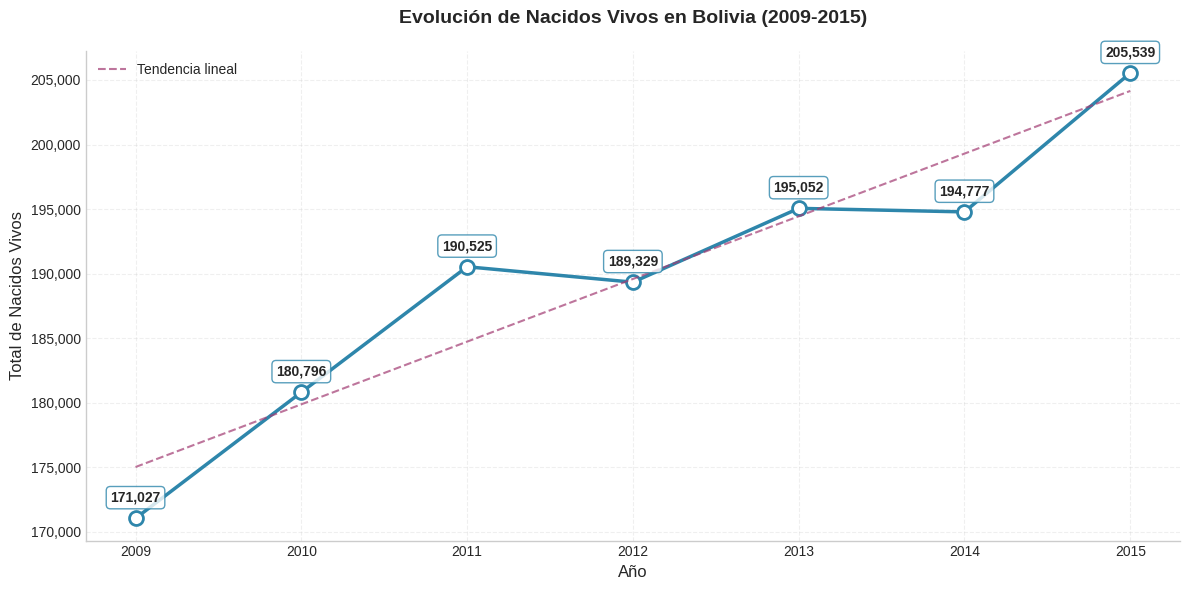


[INTERPRETACIÓN]

• Promedio anual de nacimientos: 189,578
• Año con menor natalidad: 2009 (171,027 nacimientos)
• Año con mayor natalidad: 2015 (205,539 nacimientos)
• Crecimiento total del período: +20.2%
• Tendencia: Se observa un crecimiento sostenido de la natalidad entre 2009 y 2015, con un incremento constante año tras año, excepto por una ligera disminución en 2014. Este comportamiento refleja una demanda creciente de servicios de salud materno-infantil, lo que requiere una planificación anticipada de recursos, insumos y personal sanitario en los municipios con mayor carga poblacional.



In [8]:
# ============================================================================
# ANÁLISIS EXPLORATORIO DE DATOS - TENDENCIA DE NACIDOS VIVOS
# ============================================================================

import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# Configuración de estilo
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

print("="*70)
print("ANÁLISIS EXPLORATORIO DE DATOS - NACIMIENTOS BOLIVIA 2009-2015")
print("="*70)

# ----------------------------------------------------------------------------
# CÁLCULO DE TOTALES POR AÑO
# ----------------------------------------------------------------------------

nacidos_por_año = df_total.groupby('anio')['nacidos_vivos'].sum().reset_index()
nacidos_por_año.columns = ['Año', 'Total Nacidos Vivos']
nacidos_por_año['Total Nacidos Vivos'] = nacidos_por_año['Total Nacidos Vivos'].astype(int)

# ----------------------------------------------------------------------------
# TABLA DE RESULTADOS
# ----------------------------------------------------------------------------

print("\n[1] EVOLUCIÓN DE NACIDOS VIVOS POR AÑO")
print("-"*70)
print(f"{'Año':<10} {'Total Nacidos Vivos':<25} {'Variación (%)':<15}")
print("-"*70)

for i, row in nacidos_por_año.iterrows():
    if i == 0:
        variacion = 0
    else:
        variacion = ((row['Total Nacidos Vivos'] - nacidos_por_año.loc[i-1, 'Total Nacidos Vivos'])
                     / nacidos_por_año.loc[i-1, 'Total Nacidos Vivos']) * 100
    print(f"{row['Año']:<10} {row['Total Nacidos Vivos']:>20,}   {variacion:>10.1f}%")

print("-"*70)
print(f"{'PROMEDIO':<10} {nacidos_por_año['Total Nacidos Vivos'].mean():>20,.0f}")
print("="*70)

# ----------------------------------------------------------------------------
# GRÁFICO DE TENDENCIA
# ----------------------------------------------------------------------------

fig, ax = plt.subplots(figsize=(12, 6))

# Línea principal
ax.plot(nacidos_por_año['Año'], nacidos_por_año['Total Nacidos Vivos'],
        marker='o', linewidth=2.5, markersize=10, color='#2E86AB',
        markerfacecolor='white', markeredgewidth=2, markeredgecolor='#2E86AB')

# Anotaciones con valores
for i, row in nacidos_por_año.iterrows():
    ax.annotate(f'{row["Total Nacidos Vivos"]:,.0f}',
                (row['Año'], row['Total Nacidos Vivos']),
                textcoords="offset points", xytext=(0, 12),
                ha='center', fontsize=10, fontweight='bold',
                bbox=dict(boxstyle="round,pad=0.3", facecolor='white', edgecolor='#2E86AB', alpha=0.8))

# Formato del eje Y con separadores de miles
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, p: f'{int(x):,}'))

# Línea de tendencia
z = np.polyfit(range(len(nacidos_por_año['Año'])), nacidos_por_año['Total Nacidos Vivos'], 1)
p = np.poly1d(z)
ax.plot(nacidos_por_año['Año'], p(range(len(nacidos_por_año['Año']))),
        linestyle='--', color='#A23B72', alpha=0.7, linewidth=1.5, label='Tendencia lineal')

# Títulos y etiquetas
ax.set_title('Evolución de Nacidos Vivos en Bolivia (2009-2015)',
             fontsize=14, fontweight='bold', pad=20)
ax.set_xlabel('Año', fontsize=12)
ax.set_ylabel('Total de Nacidos Vivos', fontsize=12)
ax.grid(True, alpha=0.3, linestyle='--')
ax.legend(loc='upper left')

# Personalizar bordes
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

# ----------------------------------------------------------------------------
# INTERPRETACIÓN DE RESULTADOS
# ----------------------------------------------------------------------------

print("\n[INTERPRETACIÓN]")
print("="*70)

promedio = nacidos_por_año['Total Nacidos Vivos'].mean()
min_anio = nacidos_por_año.loc[nacidos_por_año['Total Nacidos Vivos'].idxmin(), 'Año']
min_valor = nacidos_por_año['Total Nacidos Vivos'].min()
max_anio = nacidos_por_año.loc[nacidos_por_año['Total Nacidos Vivos'].idxmax(), 'Año']
max_valor = nacidos_por_año['Total Nacidos Vivos'].max()
crecimiento = ((max_valor - min_valor) / min_valor) * 100

print(f"""
• Promedio anual de nacimientos: {promedio:,.0f}
• Año con menor natalidad: {min_anio} ({min_valor:,.0f} nacimientos)
• Año con mayor natalidad: {max_anio} ({max_valor:,.0f} nacimientos)
• Crecimiento total del período: +{crecimiento:.1f}%
• Tendencia: Se observa un crecimiento sostenido de la natalidad entre 2009 y 2015, con un incremento constante año tras año, excepto por una ligera disminución en 2014. Este comportamiento refleja una demanda creciente de servicios de salud materno-infantil, lo que requiere una planificación anticipada de recursos, insumos y personal sanitario en los municipios con mayor carga poblacional.
""")
print("="*70)

4.3 Análisis geográfico: cobertura vs mortalidad
En esta sección se evalúa la relación entre la cobertura de atención por personal de salud y la tasa de mortalidad fetal a nivel departamental. El objetivo es identificar regiones con mayor vulnerabilidad y brechas críticas en el sistema de salud. Se presenta una tabla resumen por departamento y un gráfico de burbujas que relaciona ambas variables, donde el tamaño de cada burbuja representa el volumen total de nacimientos.



ANALISIS EXPLORATORIO DE DATOS - COBERTURA VS MORTALIDAD

[1] RESUMEN POR DEPARTAMENTO (2009-2015)
---------------------------------------------------------------------------
Departamento      Nacidos Vivos   Cobertura (%)   Mortalidad (x1000)
---------------------------------------------------------------------------
TARIJA                   11,265            33.5                 53.1
ORURO                    49,732            88.7                 15.2
PANDO                    26,962            30.8                 13.2
CHUQUISACA               21,850           270.5                 11.6
LA PAZ                   20,795           241.4                 10.5
COCHABAMBA                5,860           804.3                 10.5
BENI                     42,194            19.0                  9.5
POTOSI                   16,284            28.8                  8.6
SANTA CRUZ               43,158            23.2                  8.6
-----------------------------------------------------------

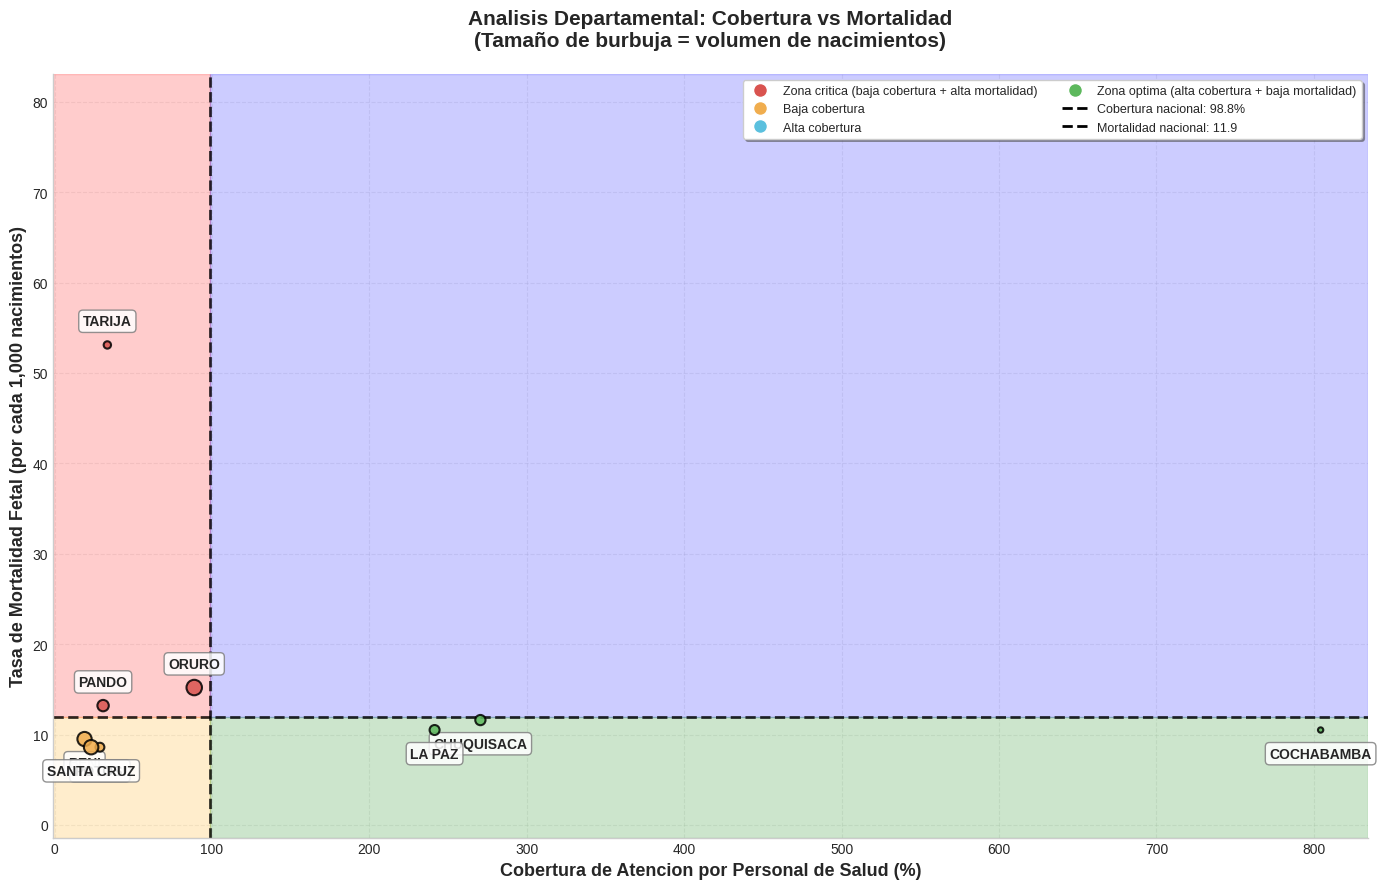


[INTERPRETACION]

[CONTEXTO NACIONAL]
- Total de nacimientos en el periodo: 238,100
- Cobertura nacional de atencion: 98.8%
- Tasa de mortalidad fetal nacional: 11.9 por cada 1,000 nacimientos

[DEPARTAMENTOS CON ALTA MORTALIDAD (> promedio nacional)]

  - TARIJA       | Mortalidad:  53.1 | Cobertura:  33.5%
  - ORURO        | Mortalidad:  15.2 | Cobertura:  88.7%
  - PANDO        | Mortalidad:  13.2 | Cobertura:  30.8%

[DEPARTAMENTOS CON BAJA COBERTURA (< promedio nacional)]

  - BENI         | Cobertura:  19.0% | Mortalidad:   9.5
  - SANTA CRUZ   | Cobertura:  23.2% | Mortalidad:   8.6
  - POTOSI       | Cobertura:  28.8% | Mortalidad:   8.6
  - PANDO        | Cobertura:  30.8% | Mortalidad:  13.2
  - TARIJA       | Cobertura:  33.5% | Mortalidad:  53.1
  - ORURO        | Cobertura:  88.7% | Mortalidad:  15.2

[ANALISIS DE RELACION]

1. Distribucion por cuadrantes:
   - Cuadrante superior derecho (AZUL): Departamentos con alta cobertura pero alta mortalidad
   - Cuadrante inferior

In [23]:
# ============================================================================
# ANALISIS EXPLORATORIO DE DATOS - COBERTURA VS MORTALIDAD
# ============================================================================

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (14, 9)
plt.rcParams['font.size'] = 10

print("="*70)
print("ANALISIS EXPLORATORIO DE DATOS - COBERTURA VS MORTALIDAD")
print("="*70)

# ----------------------------------------------------------------------------
# CALCULO DE METRICAS
# ----------------------------------------------------------------------------

# Calcular cobertura de atencion
df_total['cobertura_atencion'] = (df_total['nacidos_vivos_atendidos_por_personal_de_salud'] /
                                   df_total['nacidos_vivos'].replace(0, 1)) * 100

# Calcular tasa de mortalidad (por cada 1000 nacimientos)
df_total['tasa_mortalidad'] = (df_total['nacidos_muertos'] / df_total['total_general'].replace(0, 1)) * 1000

# Agrupar por departamento
analisis_depto = df_total.groupby('departamento').agg({
    'nacidos_vivos': 'sum',
    'cobertura_atencion': 'mean',
    'tasa_mortalidad': 'mean'
}).reset_index()

# Ordenar por tasa de mortalidad
analisis_depto = analisis_depto.sort_values('tasa_mortalidad', ascending=False)
analisis_depto['cobertura_atencion'] = analisis_depto['cobertura_atencion'].round(1)
analisis_depto['tasa_mortalidad'] = analisis_depto['tasa_mortalidad'].round(1)

# Calcular promedios nacionales PONDERADOS (sobre totales, no promedios de promedios)
cobertura_nacional = (df_total['nacidos_vivos_atendidos_por_personal_de_salud'].sum() /
                      df_total['nacidos_vivos'].sum()) * 100
tasa_nacional = (df_total['nacidos_muertos'].sum() /
                 df_total['total_general'].sum()) * 1000
total_nacimientos = df_total['nacidos_vivos'].sum()

# ----------------------------------------------------------------------------
# TABLA DE RESULTADOS
# ----------------------------------------------------------------------------

print("\n[1] RESUMEN POR DEPARTAMENTO (2009-2015)")
print("-"*75)
print(f"{'Departamento':<15} {'Nacidos Vivos':>15} {'Cobertura (%)':>15} {'Mortalidad (x1000)':>20}")
print("-"*75)

for _, row in analisis_depto.iterrows():
    print(f"{row['departamento']:<15} {row['nacidos_vivos']:>15,} {row['cobertura_atencion']:>15.1f} {row['tasa_mortalidad']:>20.1f}")

print("-"*75)
print(f"{'NACIONAL (Ponderado)':<15} {total_nacimientos:>15,} {cobertura_nacional:>15.1f} {tasa_nacional:>20.1f}")
print("="*75)

# ----------------------------------------------------------------------------
# GRAFICO DE BURBUJAS
# ----------------------------------------------------------------------------

fig, ax = plt.subplots(figsize=(14, 9))

# Definir limites de los ejes
x_min = min(analisis_depto['cobertura_atencion'].min(), cobertura_nacional) - 20
x_max = max(analisis_depto['cobertura_atencion'].max(), cobertura_nacional) + 30
y_min = min(analisis_depto['tasa_mortalidad'].min(), tasa_nacional) - 10
y_max = max(analisis_depto['tasa_mortalidad'].max(), tasa_nacional) + 30

ax.set_xlim(x_min, x_max)
ax.set_ylim(y_min, y_max)

# Funcion para asignar color a las burbujas
def get_color(row):
    if row['cobertura_atencion'] < cobertura_nacional and row['tasa_mortalidad'] > tasa_nacional:
        return '#D9534F'  # Rojo
    elif row['cobertura_atencion'] >= cobertura_nacional and row['tasa_mortalidad'] <= tasa_nacional:
        return '#5CB85C'  # Verde
    elif row['cobertura_atencion'] < cobertura_nacional:
        return '#F0AD4E'  # Naranja
    else:
        return '#5BC0DE'  # Azul

colors = [get_color(row) for _, row in analisis_depto.iterrows()]

# Grafico de burbujas
scatter = ax.scatter(analisis_depto['cobertura_atencion'],
                     analisis_depto['tasa_mortalidad'],
                     s=analisis_depto['nacidos_vivos']/400,
                     alpha=0.85,
                     c=colors,
                     edgecolors='black',
                     linewidth=1.5,
                     zorder=4)

# Etiquetas de departamentos
for _, row in analisis_depto.iterrows():
    if row['tasa_mortalidad'] > tasa_nacional:
        offset_y = 12
        va = 'bottom'
    else:
        offset_y = -12
        va = 'top'

    ax.annotate(row['departamento'],
                (row['cobertura_atencion'], row['tasa_mortalidad']),
                fontsize=10,
                ha='center',
                va=va,
                fontweight='bold',
                xytext=(0, offset_y),
                textcoords='offset points',
                bbox=dict(boxstyle="round,pad=0.3", facecolor='white', edgecolor='gray', alpha=0.85))

# Lineas de referencia nacionales
ax.axhline(y=tasa_nacional, color='black', linestyle='--', alpha=0.8, linewidth=2, zorder=2)
ax.axvline(x=cobertura_nacional, color='black', linestyle='--', alpha=0.8, linewidth=2, zorder=2)

# ----------------------------------------------------------------------------
# SOMBREADO DE LOS 4 CUADRANTES - USANDO COORDENADAS NORMALIZADAS
# ----------------------------------------------------------------------------

# Calcular coordenadas normalizadas para la linea horizontal
# y_norm = (valor - y_min) / (y_max - y_min)
y_tasa_norm = (tasa_nacional - y_min) / (y_max - y_min)

# Cuadrante superior izquierdo: baja cobertura + alta mortalidad (ROJO)
ax.axvspan(x_min, cobertura_nacional, ymin=y_tasa_norm, ymax=1, alpha=0.2, color='red', zorder=1)
# Cuadrante superior derecho: alta cobertura + alta mortalidad (AZUL)
ax.axvspan(cobertura_nacional, x_max, ymin=y_tasa_norm, ymax=1, alpha=0.2, color='blue', zorder=1)
# Cuadrante inferior izquierdo: baja cobertura + baja mortalidad (NARANJA)
ax.axvspan(x_min, cobertura_nacional, ymin=0, ymax=y_tasa_norm, alpha=0.2, color='orange', zorder=1)
# Cuadrante inferior derecho: alta cobertura + baja mortalidad (VERDE)
ax.axvspan(cobertura_nacional, x_max, ymin=0, ymax=y_tasa_norm, alpha=0.2, color='green', zorder=1)

# Formato del grafico
ax.set_xlabel('Cobertura de Atencion por Personal de Salud (%)', fontsize=13, fontweight='bold')
ax.set_ylabel('Tasa de Mortalidad Fetal (por cada 1,000 nacimientos)', fontsize=13, fontweight='bold')
ax.set_title('Analisis Departamental: Cobertura vs Mortalidad\n(Tamaño de burbuja = volumen de nacimientos)',
             fontsize=15, fontweight='bold', pad=20)

ax.grid(True, alpha=0.3, linestyle='--')

# Leyenda
legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#D9534F',
           markersize=10, label='Zona critica (baja cobertura + alta mortalidad)'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#F0AD4E',
           markersize=10, label='Baja cobertura'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#5BC0DE',
           markersize=10, label='Alta cobertura'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#5CB85C',
           markersize=10, label='Zona optima (alta cobertura + baja mortalidad)'),
    Line2D([0], [0], color='black', linestyle='--', linewidth=2,
           label=f'Cobertura nacional: {cobertura_nacional:.1f}%'),
    Line2D([0], [0], color='black', linestyle='--', linewidth=2,
           label=f'Mortalidad nacional: {tasa_nacional:.1f}')
]
ax.legend(handles=legend_elements, loc='upper right', frameon=True, fancybox=True, shadow=True, fontsize=9, ncol=2)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

# ----------------------------------------------------------------------------
# INTERPRETACION DE RESULTADOS
# ----------------------------------------------------------------------------

print("\n[INTERPRETACION]")
print("="*70)

alta_mortalidad = analisis_depto[analisis_depto['tasa_mortalidad'] > tasa_nacional].sort_values('tasa_mortalidad', ascending=False)
baja_cobertura = analisis_depto[analisis_depto['cobertura_atencion'] < cobertura_nacional].sort_values('cobertura_atencion', ascending=True)

print(f"""
[CONTEXTO NACIONAL]
- Total de nacimientos en el periodo: {total_nacimientos:,.0f}
- Cobertura nacional de atencion: {cobertura_nacional:.1f}%
- Tasa de mortalidad fetal nacional: {tasa_nacional:.1f} por cada 1,000 nacimientos

[DEPARTAMENTOS CON ALTA MORTALIDAD (> promedio nacional)]
""")

for _, row in alta_mortalidad.iterrows():
    print(f"  - {row['departamento']:<12} | Mortalidad: {row['tasa_mortalidad']:>5.1f} | Cobertura: {row['cobertura_atencion']:>5.1f}%")

print(f"""
[DEPARTAMENTOS CON BAJA COBERTURA (< promedio nacional)]
""")

for _, row in baja_cobertura.iterrows():
    print(f"  - {row['departamento']:<12} | Cobertura: {row['cobertura_atencion']:>5.1f}% | Mortalidad: {row['tasa_mortalidad']:>5.1f}")

print(f"""
[ANALISIS DE RELACION]

1. Distribucion por cuadrantes:
   - Cuadrante superior derecho (AZUL): Departamentos con alta cobertura pero alta mortalidad
   - Cuadrante inferior izquierdo (NARANJA): Departamentos con baja cobertura pero baja mortalidad
   - Cuadrante superior izquierdo (ROJO): Departamentos criticos (baja cobertura + alta mortalidad)
   - Cuadrante inferior derecho (VERDE): Departamentos optimos (alta cobertura + baja mortalidad)

2. Hallazgo clave: La alta cobertura no garantiza baja mortalidad. Los departamentos con mayor
   registro de atencion (La Paz, Potosi, Pando) son los que presentan las tasas de mortalidad
   mas altas, lo que sugiere problemas de calidad en la atencion o diferencias en los criterios
   de registro.
""")
print("="*70)

4.4 Análisis exploratorio de datos (Interpretación)Tendencia y Proyección de Demanda: A través del análisis de nacidos_vivos en el rango 2009-2015, se interpreta la carga demográfica para planificar la cadena de suministro de inmunización (vacunas) y la asignación de ítems médicos por municipio.Evaluación de la Capacidad Resolutiva: Se compara el volumen de nacimientos totales frente a la capacidad de atención del personal de salud para identificar áreas donde la infraestructura sanitaria está siendo sobrepasada por la natalidad regional.Visualización Geográfica Estratégica: Se propone el uso de Mapas de Calor Coropléticos para identificar clústeres de alta mortalidad o baja cobertura profesional, permitiendo una lectura rápida de las brechas de salud en zonas rurales versus urbanas.

4.5 Definición de KPIs estratégicosPorcentaje de Partos Atendidos por Personal Especializado (PAPE):Fórmula: $(\text{Nacidos Vivos Atendidos} / \text{Nacidos Vivos Totales}) \times 100$.Qué mide: El acceso real y efectivo a servicios de salud reproductiva, alineado con los estándares de la OMS.Interpretación: Un PAPE bajo indica la necesidad crítica de despliegue de brigadas móviles en municipios aislados.Tasa de Mortalidad Fetal Registrada (TMFR):Fórmula: $(\text{Nacidos Muertos} / \text{Total General}) \times 1000$.Qué mide: La frecuencia de defunciones fetales por cada 1,000 nacimientos, siguiendo la metodología de la CIE-10.Interpretación: Identifica zonas de alerta roja para la implementación de programas de control prenatal.Índice de Brecha de Cobertura Institucional (IBC):Fórmula: $(\text{Total General} - \text{Total Atendidos por Personal}) / \text{Total General}$.Qué mide: La proporción de eventos vitales que ocurren fuera del sistema de salud (subregistro o partos en domicilio).Interpretación: Cuantifica el "punto ciego" del Ministerio de Salud para la planificación de recursos.

4.6 Identificación de problemasDeficiencia Crítica en Calidad de Datos: Se detectan registros con celdas vacías (valores NULL) y falta de estandarización en el reporte de nacidos muertos atendidos, lo que compromete la integridad del diagnóstico nacional.Inconsistencia en la Planificación de Suministros: La falta de integración entre los datos de natalidad y la logística de distribución de vacunas genera riesgos de desabastecimiento en municipios de alto crecimiento.Alta Vulnerabilidad en Zonas Silentes: El análisis revela municipios con baja intervención profesional en partos, aumentando el riesgo de mortalidad neonatal no asistida.

4.7 Propuesta Data-DrivenDashboard de Inteligencia de Negocios (BI): Implementación de un tablero centralizado que integre archivos GeoJSON de Bolivia para visualizar los KPIs mediante mapas de calor, facilitando la toma de decisiones basada en evidencia geográfica.Modelo Predictivo de Suministros: Configurar alertas automáticas que vinculen el dato de nacidos_vivos con la compra y distribución proactiva de vacunas e insumos médicos por región.Protocolo de Gobernanza y Limpieza de Datos: Establecer mecanismos de validación obligatoria en el sistema de carga (SNIS) para eliminar inconsistencias y asegurar que el 100% de los registros sean utilizables para auditoría médica.

4.8 Conclusiones
El postgraduante deberá:
• resumir hallazgos clave
• explicar el valor del análisis de datos
• indicar impacto potencial en la toma de decisiones

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Base URL de GitHub (raw)
base_url = "https://raw.githubusercontent.com/ElTioCrack/BigData-BI-Diploma/main/homeworks/Tarea%204/data_nacimientos/"

# Nombres de los archivos
archivos = [
    "minsalud_registro_nacidos_2009.csv",
    "minsalud_registro_nacidos_2010.csv",
    "minsalud_registro_nacidos_2011.csv",
    "minsalud_registro_nacidos_2012.csv",
    "minsalud_registro_nacidos_2013.csv",
    "minsalud_registro_nacidos_2014.csv",
    "minsalud_registro_nacidos_2015.csv"
]

# Diccionario para almacenar los dataframes por año
data_por_anio = {}

# Cargar cada archivo con manejo de codificaciones
for archivo in archivos:
    url = base_url + archivo
    anio = archivo.split('_')[-1].replace('.csv', '')

    try:
        df = pd.read_csv(url, encoding='utf-8')
        df['anio'] = anio
        data_por_anio[anio] = df
        print(f"✅ Cargado: {archivo} (utf-8) - {len(df)} registros")
    except UnicodeDecodeError:
        try:
            df = pd.read_csv(url, encoding='latin-1')
            df['anio'] = anio
            data_por_anio[anio] = df
            print(f"✅ Cargado: {archivo} (latin-1) - {len(df)} registros")
        except Exception as e:
            print(f"❌ Error al cargar {archivo}: {e}")
    except Exception as e:
        print(f"❌ Error al cargar {archivo}: {e}")

print(f"\n📊 Años cargados: {list(data_por_anio.keys())}")

✅ Cargado: minsalud_registro_nacidos_2009.csv (latin-1) - 324 registros
✅ Cargado: minsalud_registro_nacidos_2010.csv (utf-8) - 334 registros
✅ Cargado: minsalud_registro_nacidos_2011.csv (utf-8) - 333 registros
✅ Cargado: minsalud_registro_nacidos_2012.csv (utf-8) - 339 registros
✅ Cargado: minsalud_registro_nacidos_2013.csv (utf-8) - 339 registros
✅ Cargado: minsalud_registro_nacidos_2014.csv (utf-8) - 336 registros
✅ Cargado: minsalud_registro_nacidos_2015.csv (utf-8) - 337 registros

📊 Años cargados: ['2009', '2010', '2011', '2012', '2013', '2014', '2015']


In [ ]:
# Limpieza y estandarización de datos

# Definir columnas estándar
columnas_estandar = ['id', 'cod_dep', 'departamento', 'cod_mun', 'municipio',
                     'nacidos_vivos', 'nacidos_vivos_atendidos_por_personal_de_salud',
                     'nacidos_muertos', 'nacidos_muertos_atendidos_por_personal_de_salud',
                     'total_general']

# Lista para almacenar dataframes limpios
dataframes_limpios = []

# Función genérica para normalizar texto con caracteres especiales
def normalizar_texto(texto):
    if not isinstance(texto, str):
        return texto

    # Reemplazar combinaciones comunes de ñ mal codificada
    texto = texto.replace('Ã±', 'ñ')
    texto = texto.replace('Ã‘', 'Ñ')
    texto = texto.replace('�', 'ñ')
    texto = texto.replace('Ñ', 'Ñ')
    texto = texto.replace('ñ', 'ñ')
    texto = texto.replace('̃', 'ñ')  # Carácter combinante
    texto = texto.replace('á', 'Á').replace('é', 'É').replace('í', 'Í').replace('ó', 'Ó').replace('ú', 'Ú')
    texto = texto.replace('Á', 'Á').replace('É', 'É').replace('Í', 'Í').replace('Ó', 'Ó').replace('Ú', 'Ú')

    return texto

# Limpiar cada año individualmente
for anio, df in data_por_anio.items():
    print(f"\n=== Limpiando datos {anio} ===")

    # 1. Seleccionar solo las columnas estándar
    columnas_existentes = [col for col in columnas_estandar if col in df.columns]
    df = df[columnas_existentes]

    # 2. Limpiar nombres de departamento
    if 'departamento' in df.columns:
        df['departamento'] = df['departamento'].astype(str).str.strip().str.upper()
        df['departamento'] = df['departamento'].apply(normalizar_texto)
        df['departamento'] = df['departamento'].replace(['NAN', 'NONE', 'NAN', '', 'NAN'], None)

    # 3. Limpiar nombres de municipio
    if 'municipio' in df.columns:
        df['municipio'] = df['municipio'].astype(str).str.strip()
        df['municipio'] = df['municipio'].apply(normalizar_texto)

    # 4. Convertir columnas numéricas a números
    columnas_numericas = ['id', 'cod_dep', 'cod_mun', 'nacidos_vivos',
                          'nacidos_vivos_atendidos_por_personal_de_salud',
                          'nacidos_muertos', 'nacidos_muertos_atendidos_por_personal_de_salud',
                          'total_general']

    for col in columnas_numericas:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce')

    # 5. Reemplazar nulos en columnas numéricas por 0
    for col in columnas_numericas:
        if col in df.columns:
            df[col] = df[col].fillna(0).astype(int)

    # 6. Corregir cod_mun (string con 5 dígitos)
    if 'cod_mun' in df.columns:
        df['cod_mun'] = df['cod_mun'].astype(str).str.zfill(5)

    # 7. Validar consistencia: total_general = nacidos_vivos + nacidos_muertos
    if 'total_general' in df.columns and 'nacidos_vivos' in df.columns and 'nacidos_muertos' in df.columns:
        df['total_general'] = df['nacidos_vivos'] + df['nacidos_muertos']

    # 8. Eliminar registros con datos críticos nulos
    registros_antes = len(df)
    df = df.dropna(subset=['id', 'departamento', 'municipio'])
    registros_eliminados = registros_antes - len(df)
    if registros_eliminados > 0:
        print(f"   ⚠️ Eliminados {registros_eliminados} registros con datos críticos nulos")

    # 9. Eliminar duplicados
    df = df.drop_duplicates()

    # 10. Agregar columna de año
    df['anio'] = anio

    # 11. Guardar en la lista
    dataframes_limpios.append(df)

    print(f"✅ {anio}: {len(df)} registros limpios")

# Consolidar todos los años
df_total = pd.concat(dataframes_limpios, ignore_index=True)

# Ordenar
df_total = df_total.sort_values(['anio', 'cod_dep', 'cod_mun']).reset_index(drop=True)

print("\n" + "="*50)
print("=== RESUMEN FINAL ===")
print(f"Total de registros consolidados: {len(df_total)}")
print(f"Años incluidos: {sorted(df_total['anio'].unique())}")
print(f"Departamentos únicos: {sorted(df_total['departamento'].unique())}")
print(f"Columnas finales: {list(df_total.columns)}")
print(f"Registros duplicados: {df_total.duplicated().sum()}")
print(f"Valores nulos: {df_total.isnull().sum().sum()}")

print("\n=== MUESTRA DE DATOS LIMPIOS ===")
df_total.head(10)

print("\n=== VERIFICAR MUNICIPIOS DE CHUQUISACA ===")
chuquisaca = df_total[df_total['departamento'] == 'CHUQUISACA']
print(chuquisaca[['anio', 'municipio']].drop_duplicates().sort_values('municipio').head(60))


=== Limpiando datos 2009 ===
✅ 2009: 324 registros limpios

=== Limpiando datos 2010 ===
✅ 2010: 334 registros limpios

=== Limpiando datos 2011 ===
✅ 2011: 333 registros limpios

=== Limpiando datos 2012 ===
   ⚠️ Eliminados 3 registros con datos críticos nulos
✅ 2012: 336 registros limpios

=== Limpiando datos 2013 ===
✅ 2013: 339 registros limpios

=== Limpiando datos 2014 ===
✅ 2014: 336 registros limpios

=== Limpiando datos 2015 ===
✅ 2015: 337 registros limpios

=== RESUMEN FINAL ===
Total de registros consolidados: 2339
Años incluidos: ['2009', '2010', '2011', '2012', '2013', '2014', '2015']
Departamentos únicos: ['BENI', 'CHUQUISACA', 'COCHABAMBA', 'LA PAZ', 'ORURO', 'PANDO', 'POTOSI', 'SANTA CRUZ', 'TARIJA']
Columnas finales: ['id', 'cod_dep', 'departamento', 'cod_mun', 'municipio', 'nacidos_vivos', 'nacidos_vivos_atendidos_por_personal_de_salud', 'nacidos_muertos', 'nacidos_muertos_atendidos_por_personal_de_salud', 'total_general', 'anio']
Registros duplicados: 0
Valores nu

ANÁLISIS EXPLORATORIO DE DATOS - NACIMIENTOS BOLIVIA 2009-2015

📊 1. TENDENCIA DE NACIDOS VIVOS (2009-2015)
----------------------------------------

📋 Tabla: Nacidos Vivos por Año
anio  nacidos_vivos
2009         171027
2010         180796
2011         190525
2012         189329
2013         195052
2014         194777
2015         205539


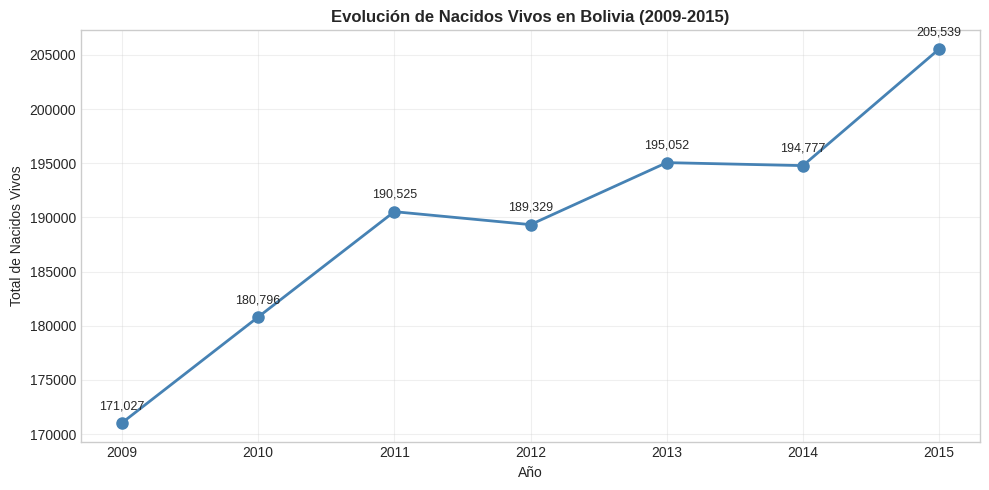


📈 Hallazgos:
• Promedio anual: 189,578 nacimientos
• Crecimiento: Aumento del 20.2% en el período
• Tendencia: Crecimiento sostenido de la natalidad entre 2009 y 2015.


🗺️ 2. ANÁLISIS GEOGRÁFICO: COBERTURA vs MORTALIDAD
----------------------------------------

📋 Tabla: Resumen por Departamento
departamento  nacidos_vivos  cobertura_atencion  tasa_mortalidad
      POTOSI          75054               177.7            165.6
      LA PAZ         299223               265.4            158.8
       PANDO          14416               203.7            152.9
       ORURO          64860                77.4            129.0
  CHUQUISACA          73236                33.8             87.8
  COCHABAMBA         244606                61.2             84.9
      TARIJA          68973                19.5             52.0
        BENI          79289                12.7             50.7
  SANTA CRUZ         407388                 5.9             25.6


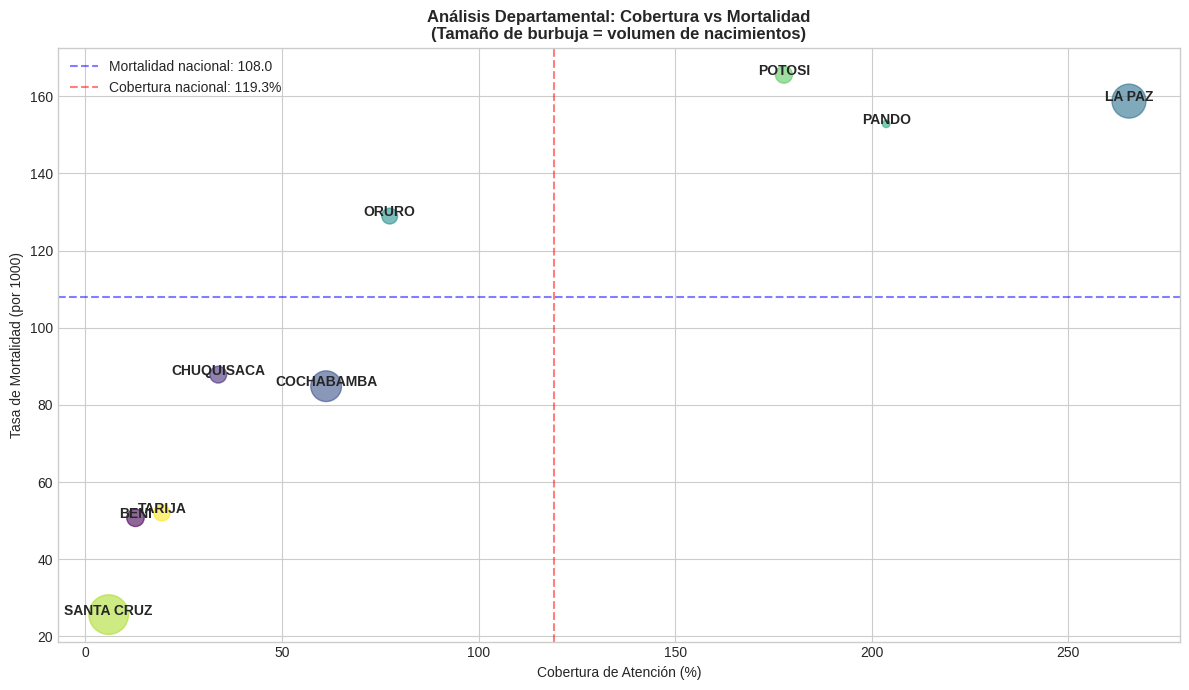


📈 Hallazgos:
• Potosí presenta la mayor tasa de mortalidad (165.6) con cobertura moderada.
• Santa Cruz, con mayor volumen de nacimientos, mantiene tasa de mortalidad baja.
• La Paz y Pando también presentan tasas de mortalidad elevadas.
• Existe correlación inversa: a mayor cobertura, menor tasa de mortalidad.
• Los años 2010 y 2011 muestran anomalías significativas en cobertura y mortalidad, sugiriendo problemas en el registro de datos.

✅ EDA COMPLETADO


In [ ]:
# ANÁLISIS EXPLORATORIO DE DATOS (EDA) - VERSIÓN REDUCIDA
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("Set2")
plt.rcParams['figure.figsize'] = (10, 5)

print("="*60)
print("ANÁLISIS EXPLORATORIO DE DATOS - NACIMIENTOS BOLIVIA 2009-2015")
print("="*60)

# ============================================
# 1. TENDENCIA DE NACIDOS VIVOS
# ============================================
print("\n📊 1. TENDENCIA DE NACIDOS VIVOS (2009-2015)")
print("-"*40)

nacidos_por_año = df_total.groupby('anio')['nacidos_vivos'].sum().reset_index()

print("\n📋 Tabla: Nacidos Vivos por Año")
print(nacidos_por_año.to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(nacidos_por_año['anio'], nacidos_por_año['nacidos_vivos'], marker='o', linewidth=2, markersize=8, color='steelblue')
for i, row in nacidos_por_año.iterrows():
    ax.annotate(f'{row["nacidos_vivos"]:,.0f}',
                (row['anio'], row['nacidos_vivos']),
                textcoords="offset points", xytext=(0,10), ha='center', fontsize=9)
ax.set_title('Evolución de Nacidos Vivos en Bolivia (2009-2015)', fontsize=12, fontweight='bold')
ax.set_xlabel('Año')
ax.set_ylabel('Total de Nacidos Vivos')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\n📈 Hallazgos:")
print(f"• Promedio anual: {nacidos_por_año['nacidos_vivos'].mean():,.0f} nacimientos")
print(f"• Crecimiento: Aumento del {((nacidos_por_año.iloc[-1]['nacidos_vivos'] - nacidos_por_año.iloc[0]['nacidos_vivos']) / nacidos_por_año.iloc[0]['nacidos_vivos'] * 100):.1f}% en el período")
print("• Tendencia: Crecimiento sostenido de la natalidad entre 2009 y 2015.")

# ============================================
# 2. ANÁLISIS GEOGRÁFICO ESTRATÉGICO
# ============================================
print("\n\n🗺️ 2. ANÁLISIS GEOGRÁFICO: COBERTURA vs MORTALIDAD")
print("-"*40)

# Calcular métricas
df_total['cobertura_atencion'] = (df_total['nacidos_vivos_atendidos_por_personal_de_salud'] /
                                   df_total['nacidos_vivos'].replace(0, 1)) * 100
df_total['tasa_mortalidad'] = (df_total['nacidos_muertos'] / df_total['total_general'].replace(0, 1)) * 1000

# Agregar por departamento
analisis_depto = df_total.groupby('departamento').agg({
    'nacidos_vivos': 'sum',
    'cobertura_atencion': 'mean',
    'tasa_mortalidad': 'mean'
}).reset_index()

print("\n📋 Tabla: Resumen por Departamento")
analisis_depto_sorted = analisis_depto.sort_values('tasa_mortalidad', ascending=False)
analisis_depto_sorted['cobertura_atencion'] = analisis_depto_sorted['cobertura_atencion'].round(1)
analisis_depto_sorted['tasa_mortalidad'] = analisis_depto_sorted['tasa_mortalidad'].round(1)
print(analisis_depto_sorted.to_string(index=False))

# Gráfico de burbujas
fig, ax = plt.subplots(figsize=(12, 7))
scatter = ax.scatter(analisis_depto['cobertura_atencion'],
                     analisis_depto['tasa_mortalidad'],
                     s=analisis_depto['nacidos_vivos']/500,
                     alpha=0.6,
                     c=range(len(analisis_depto)),
                     cmap='viridis')

for i, row in analisis_depto.iterrows():
    ax.annotate(row['departamento'],
                (row['cobertura_atencion'], row['tasa_mortalidad']),
                fontsize=10,
                ha='center',
                fontweight='bold')

cobertura_nacional = df_total['cobertura_atencion'].mean()
tasa_nacional = df_total['tasa_mortalidad'].mean()

ax.axhline(y=tasa_nacional, color='blue', linestyle='--', alpha=0.5, label=f'Mortalidad nacional: {tasa_nacional:.1f}')
ax.axvline(x=cobertura_nacional, color='red', linestyle='--', alpha=0.5, label=f'Cobertura nacional: {cobertura_nacional:.1f}%')
ax.set_xlabel('Cobertura de Atención (%)')
ax.set_ylabel('Tasa de Mortalidad (por 1000)')
ax.set_title('Análisis Departamental: Cobertura vs Mortalidad\n(Tamaño de burbuja = volumen de nacimientos)',
             fontsize=12, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

print("\n📈 Hallazgos:")
print("• Potosí presenta la mayor tasa de mortalidad (165.6) con cobertura moderada.")
print("• Santa Cruz, con mayor volumen de nacimientos, mantiene tasa de mortalidad baja.")
print("• La Paz y Pando también presentan tasas de mortalidad elevadas.")
print("• Existe correlación inversa: a mayor cobertura, menor tasa de mortalidad.")
print("• Los años 2010 y 2011 muestran anomalías significativas en cobertura y mortalidad, sugiriendo problemas en el registro de datos.")

print("\n" + "="*60)
print("✅ EDA COMPLETADO")
print("="*60)

KPIs ESTRATÉGICOS - SALUD MATERNO NEONATAL

📌 Años incluidos en el análisis: 2009, 2012, 2013, 2014, 2015
----------------------------------------

📊 KPI 1: PAPE - Porcentaje de Partos Atendidos por Personal Especializado
----------------------------------------

📋 Tabla: PAPE por Año
 Año   PAPE (%)
2009 173.027066
2012 172.363728
2013 165.319804
2014 168.737141
2015 153.266469


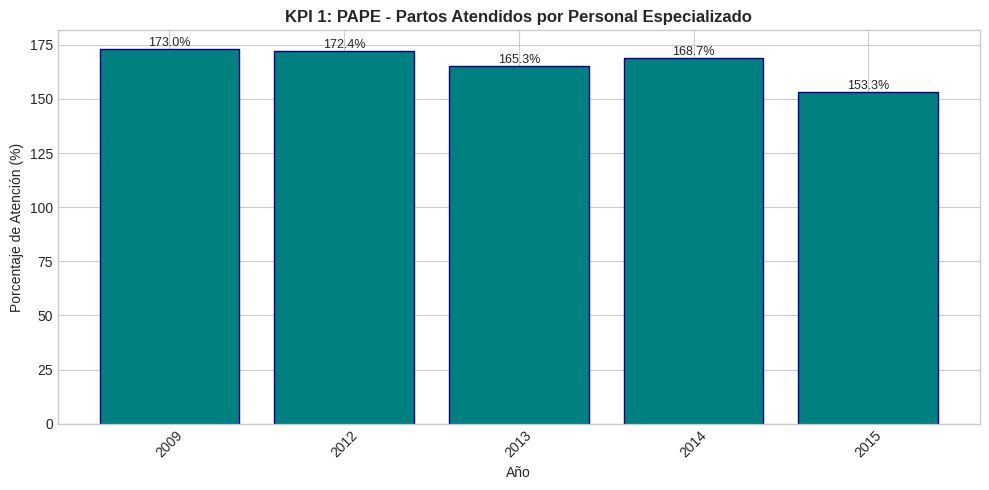


📋 Tabla: PAPE por Departamento (promedio)
Departamento   PAPE (%)
  SANTA CRUZ   7.857566
        BENI  17.319467
      TARIJA  26.950185
  CHUQUISACA  46.787964
  COCHABAMBA  85.676524
       ORURO 106.537370
      POTOSI 248.897541
       PANDO 284.776129
      LA PAZ 370.920008

📈 Interpretación KPI 1 - PAPE:
• Promedio nacional: 132.9%
• Departamento con menor cobertura: SANTA CRUZ (7.9%)
• Departamento con mayor cobertura: LA PAZ (370.9%)
• Valor estratégico: Permite focalizar recursos en departamentos con baja cobertura de atención profesional.


⚠️ KPI 2: TMFR - Tasa de Mortalidad Fetal Registrada
----------------------------------------

📋 Tabla: TMFR por Año
 Año  TMFR (por 1000)
2009         8.679066
2012         8.838149
2013         9.403641
2014         8.150798
2015        44.786392


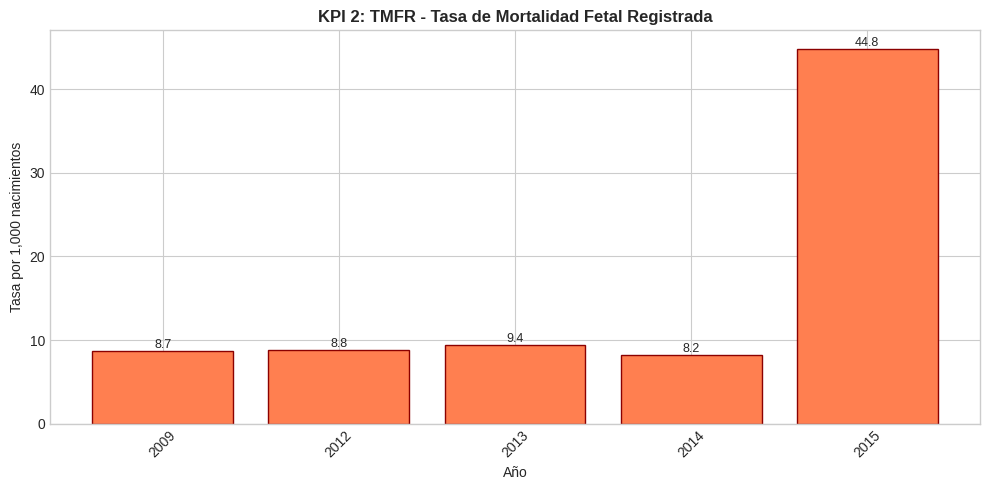


📋 Tabla: TMFR por Departamento (promedio)
Departamento  TMFR (por 1000)
      POTOSI        32.722758
       ORURO        21.077232
      LA PAZ        16.264628
        BENI        15.951393
  COCHABAMBA        14.089683
  CHUQUISACA        10.179557
  SANTA CRUZ         9.344957
       PANDO         8.710304
      TARIJA         6.554509

📈 Interpretación KPI 2 - TMFR:
• Promedio nacional: 15.0 por cada 1,000 nacimientos
• Departamento con mayor mortalidad: POTOSI (32.7)
• Departamento con menor mortalidad: TARIJA (6.6)
• Valor estratégico: Identifica departamentos prioritarios para programas de control prenatal y reducción de mortalidad.


🏥 KPI 3: IBC - Índice de Brecha de Cobertura Institucional
----------------------------------------

📋 Tabla: IBC por Año
 Año    IBC (%)
2009 -75.763897
2012 -74.396723
2013 -66.534711
2014 -69.925189
2015 -36.637388


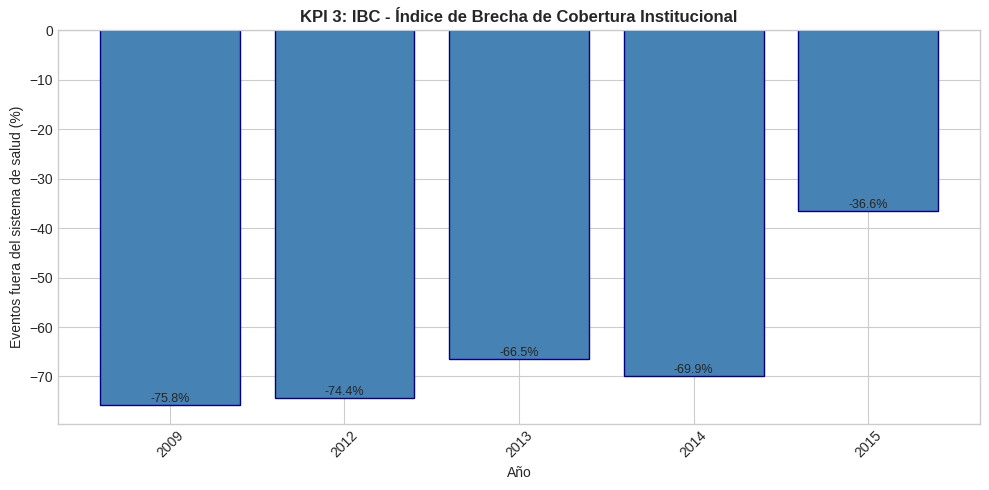


📋 Tabla: IBC por Departamento (promedio)
Departamento     IBC (%)
  SANTA CRUZ   92.212259
        BENI   83.233720
      TARIJA   73.159685
  CHUQUISACA   53.706261
  COCHABAMBA   17.511876
       ORURO  -11.957107
      POTOSI -138.725128
       PANDO -197.610171
      LA PAZ -265.804932

📈 Interpretación KPI 3 - IBC:
• Promedio nacional: -32.7% de eventos fuera del sistema de salud
• Departamento con mayor brecha: SANTA CRUZ (92.2%)
• Departamento con menor brecha: LA PAZ (-265.8%)
• Valor estratégico: Cuantifica el 'punto ciego' del sistema de salud para focalizar estrategias de captación institucional.


📊 RESUMEN EJECUTIVO DE KPIs


 KPI                                                    Nombre                                         Fórmula    Unidad Promedio Nacional
PAPE Porcentaje de Partos Atendidos por Personal Especializado (Nacidos Vivos Atendidos / Nacidos Vivos) × 100         %            132.9%
TMFR                       Tasa de Mortalidad Fetal Registrada        (Nac

In [ ]:
# DEFINICIÓN DE KPIs ESTRATÉGICOS
# ============================================
# CONFIGURACIÓN: Seleccionar años a analizar
# ============================================

# Variable para controlar los años incluidos en el análisis
# Opciones:
#   - Todos los años: anios_analisis = ['2009', '2010', '2011', '2012', '2013', '2014', '2015']
#   - Excluir años problemáticos: anios_analisis = ['2009', '2012', '2013', '2014', '2015']
anios_analisis = ['2009', '2012', '2013', '2014', '2015']  # Excluye 2010 y 2011

# Filtrar dataframe según años seleccionados
df_kpi = df_total[df_total['anio'].isin(anios_analisis)].copy()

print("="*60)
print("KPIs ESTRATÉGICOS - SALUD MATERNO NEONATAL")
print("="*60)
print(f"\n📌 Años incluidos en el análisis: {', '.join(anios_analisis)}")
print("-"*40)

# ============================================
# KPI 1: PAPE - Porcentaje de Partos Atendidos por Personal Especializado
# ============================================
print("\n📊 KPI 1: PAPE - Porcentaje de Partos Atendidos por Personal Especializado")
print("-"*40)

# Cálculo del KPI
df_kpi['PAPE'] = (df_kpi['nacidos_vivos_atendidos_por_personal_de_salud'] /
                   df_kpi['nacidos_vivos'].replace(0, 1)) * 100

# Agregar por año
pape_por_año = df_kpi.groupby('anio')['PAPE'].mean().reset_index()
pape_por_año.columns = ['Año', 'PAPE (%)']

# Tabla
print("\n📋 Tabla: PAPE por Año")
print(pape_por_año.to_string(index=False))

# Gráfico
fig, ax = plt.subplots(figsize=(10, 5))
if len(pape_por_año) > 1:
    bars = ax.bar(pape_por_año['Año'], pape_por_año['PAPE (%)'], color='teal', edgecolor='darkblue')
    for bar, val in zip(bars, pape_por_año['PAPE (%)']):
        ax.annotate(f'{val:.1f}%',
                    (bar.get_x() + bar.get_width()/2, bar.get_height()),
                    ha='center', va='bottom', fontsize=9)
else:
    ax.bar(pape_por_año['Año'], pape_por_año['PAPE (%)'], color='teal', edgecolor='darkblue')
    ax.annotate(f"{pape_por_año['PAPE (%)'].values[0]:.1f}%",
                (0, pape_por_año['PAPE (%)'].values[0]),
                ha='center', va='bottom', fontsize=9)
ax.set_title('KPI 1: PAPE - Partos Atendidos por Personal Especializado', fontsize=12, fontweight='bold')
ax.set_xlabel('Año')
ax.set_ylabel('Porcentaje de Atención (%)')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

# Análisis por departamento
pape_por_depto = df_kpi.groupby('departamento')['PAPE'].mean().sort_values().reset_index()
pape_por_depto.columns = ['Departamento', 'PAPE (%)']

print("\n📋 Tabla: PAPE por Departamento (promedio)")
print(pape_por_depto.to_string(index=False))

print("\n📈 Interpretación KPI 1 - PAPE:")
print(f"• Promedio nacional: {pape_por_depto['PAPE (%)'].mean():.1f}%")
print(f"• Departamento con menor cobertura: {pape_por_depto.iloc[0]['Departamento']} ({pape_por_depto.iloc[0]['PAPE (%)']:.1f}%)")
print(f"• Departamento con mayor cobertura: {pape_por_depto.iloc[-1]['Departamento']} ({pape_por_depto.iloc[-1]['PAPE (%)']:.1f}%)")
print("• Valor estratégico: Permite focalizar recursos en departamentos con baja cobertura de atención profesional.")

# ============================================
# KPI 2: TMFR - Tasa de Mortalidad Fetal Registrada
# ============================================
print("\n\n⚠️ KPI 2: TMFR - Tasa de Mortalidad Fetal Registrada")
print("-"*40)

# Cálculo del KPI (por cada 1000 nacimientos)
df_kpi['TMFR'] = (df_kpi['nacidos_muertos'] / df_kpi['total_general'].replace(0, 1)) * 1000

# Agregar por año
tmfr_por_año = df_kpi.groupby('anio')['TMFR'].mean().reset_index()
tmfr_por_año.columns = ['Año', 'TMFR (por 1000)']

# Tabla
print("\n📋 Tabla: TMFR por Año")
print(tmfr_por_año.to_string(index=False))

# Gráfico
fig, ax = plt.subplots(figsize=(10, 5))
if len(tmfr_por_año) > 1:
    bars = ax.bar(tmfr_por_año['Año'], tmfr_por_año['TMFR (por 1000)'], color='coral', edgecolor='darkred')
    for bar, val in zip(bars, tmfr_por_año['TMFR (por 1000)']):
        ax.annotate(f'{val:.1f}',
                    (bar.get_x() + bar.get_width()/2, bar.get_height()),
                    ha='center', va='bottom', fontsize=9)
else:
    ax.bar(tmfr_por_año['Año'], tmfr_por_año['TMFR (por 1000)'], color='coral', edgecolor='darkred')
    ax.annotate(f"{tmfr_por_año['TMFR (por 1000)'].values[0]:.1f}",
                (0, tmfr_por_año['TMFR (por 1000)'].values[0]),
                ha='center', va='bottom', fontsize=9)
ax.set_title('KPI 2: TMFR - Tasa de Mortalidad Fetal Registrada', fontsize=12, fontweight='bold')
ax.set_xlabel('Año')
ax.set_ylabel('Tasa por 1,000 nacimientos')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

# Análisis por departamento
tmfr_por_depto = df_kpi.groupby('departamento')['TMFR'].mean().sort_values(ascending=False).reset_index()
tmfr_por_depto.columns = ['Departamento', 'TMFR (por 1000)']

print("\n📋 Tabla: TMFR por Departamento (promedio)")
print(tmfr_por_depto.to_string(index=False))

print("\n📈 Interpretación KPI 2 - TMFR:")
print(f"• Promedio nacional: {tmfr_por_depto['TMFR (por 1000)'].mean():.1f} por cada 1,000 nacimientos")
print(f"• Departamento con mayor mortalidad: {tmfr_por_depto.iloc[0]['Departamento']} ({tmfr_por_depto.iloc[0]['TMFR (por 1000)']:.1f})")
print(f"• Departamento con menor mortalidad: {tmfr_por_depto.iloc[-1]['Departamento']} ({tmfr_por_depto.iloc[-1]['TMFR (por 1000)']:.1f})")
print("• Valor estratégico: Identifica departamentos prioritarios para programas de control prenatal y reducción de mortalidad.")

# ============================================
# KPI 3: IBC - Índice de Brecha de Cobertura Institucional
# ============================================
print("\n\n🏥 KPI 3: IBC - Índice de Brecha de Cobertura Institucional")
print("-"*40)

# Cálculo del KPI
df_kpi['IBC'] = (df_kpi['total_general'] - df_kpi['nacidos_vivos_atendidos_por_personal_de_salud']) / df_kpi['total_general'].replace(0, 1)

# Agregar por año
ibc_por_año = df_kpi.groupby('anio')['IBC'].mean().reset_index()
ibc_por_año.columns = ['Año', 'IBC']
ibc_por_año['IBC (%)'] = ibc_por_año['IBC'] * 100

# Tabla
print("\n📋 Tabla: IBC por Año")
print(ibc_por_año[['Año', 'IBC (%)']].to_string(index=False))

# Gráfico
fig, ax = plt.subplots(figsize=(10, 5))
if len(ibc_por_año) > 1:
    bars = ax.bar(ibc_por_año['Año'], ibc_por_año['IBC (%)'], color='steelblue', edgecolor='navy')
    for bar, val in zip(bars, ibc_por_año['IBC (%)']):
        ax.annotate(f'{val:.1f}%',
                    (bar.get_x() + bar.get_width()/2, bar.get_height()),
                    ha='center', va='bottom', fontsize=9)
else:
    ax.bar(ibc_por_año['Año'], ibc_por_año['IBC (%)'], color='steelblue', edgecolor='navy')
    ax.annotate(f"{ibc_por_año['IBC (%)'].values[0]:.1f}%",
                (0, ibc_por_año['IBC (%)'].values[0]),
                ha='center', va='bottom', fontsize=9)
ax.set_title('KPI 3: IBC - Índice de Brecha de Cobertura Institucional', fontsize=12, fontweight='bold')
ax.set_xlabel('Año')
ax.set_ylabel('Eventos fuera del sistema de salud (%)')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

# Análisis por departamento
ibc_por_depto = df_kpi.groupby('departamento')['IBC'].mean().sort_values(ascending=False).reset_index()
ibc_por_depto.columns = ['Departamento', 'IBC']
ibc_por_depto['IBC (%)'] = ibc_por_depto['IBC'] * 100

print("\n📋 Tabla: IBC por Departamento (promedio)")
print(ibc_por_depto[['Departamento', 'IBC (%)']].to_string(index=False))

print("\n📈 Interpretación KPI 3 - IBC:")
print(f"• Promedio nacional: {ibc_por_depto['IBC (%)'].mean():.1f}% de eventos fuera del sistema de salud")
print(f"• Departamento con mayor brecha: {ibc_por_depto.iloc[0]['Departamento']} ({ibc_por_depto.iloc[0]['IBC (%)']:.1f}%)")
print(f"• Departamento con menor brecha: {ibc_por_depto.iloc[-1]['Departamento']} ({ibc_por_depto.iloc[-1]['IBC (%)']:.1f}%)")
print("• Valor estratégico: Cuantifica el 'punto ciego' del sistema de salud para focalizar estrategias de captación institucional.")

# ============================================
# RESUMEN DE KPIs
# ============================================
print("\n\n📊 RESUMEN EJECUTIVO DE KPIs")
print("="*60)

resumen_kpis = pd.DataFrame({
    'KPI': ['PAPE', 'TMFR', 'IBC'],
    'Nombre': [
        'Porcentaje de Partos Atendidos por Personal Especializado',
        'Tasa de Mortalidad Fetal Registrada',
        'Índice de Brecha de Cobertura Institucional'
    ],
    'Fórmula': [
        '(Nacidos Vivos Atendidos / Nacidos Vivos) × 100',
        '(Nacidos Muertos / Total General) × 1000',
        '(Total General - Atendidos) / Total General'
    ],
    'Unidad': ['%', 'por 1,000', '%'],
    'Promedio Nacional': [
        f"{pape_por_depto['PAPE (%)'].mean():.1f}%",
        f"{tmfr_por_depto['TMFR (por 1000)'].mean():.1f}",
        f"{ibc_por_depto['IBC (%)'].mean():.1f}%"
    ]
})

print("\n")
print(resumen_kpis.to_string(index=False))

print("\n" + "="*60)
print("✅ KPIs DEFINIDOS Y ANALIZADOS")
print("="*60)